***Я выбрала известный датасет "Hotel Booking Demand"(спрос на бронирование отелей). Он является "золотым стандартом" для EDA, потому что в нем есть всё: даты, деньги, категории клиентов и целевая переменная (is_canceled).***

**Гипотезы исследования:**

**H1**: Чем больше глубина бронирования (lead_time), тем выше вероятность отмены (is_canceled).

**H2**: В Resort Hotel средний чек (adr) выше, чем в City Hotel, особенно в летние месяцы.

**H3**: Повторные гости (is_repeated_guest) реже отменяют бронь.

**H4**: Наличие детей (children > 0) увеличивает количество спецзапросов (total_of_special_requests).

**H5**: Если тип номера изменился при заселении (reserved_room_type != assigned_room_type), то ADR падает (понижение категории) или растет (повышение).

**H6**: Гости из Португалии (PRT) имеют самый высокий процент отмен (потому что местные проще относятся к планам).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from scipy import stats

In [6]:
df = pd.read_csv('~/Downloads/hotel_booking_data_cleaned.csv')

In [7]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,06/09/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,07/09/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,07/09/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,07/09/2017


In [8]:
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,21/10/2015
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


### Анализ структуры данных

Датасет содержит **119 390 записей** и **32 признака**.

**Проблемы с данными, выявленные на этапе df.info():**
1. **Критичные пропуски:** 
   - `company` (94% пропусков) - столбец будет удален из анализа ввиду полной неинформативности.
   - `agent` (13% пропусков) - столбец исключен из визуализации корреляций, т.к. содержит ID.
2. **Незначительные пропуски:**
   - `children` (4 пропуска) - будут заполнены медианой (0).
   - `country` (488 пропусков) - будут заменены на моду (самое частое значение) или метку 'UNK'.
3. **Типы данных:**
   - Колонка `children` имеет тип **float64**, хотя должна быть **int64**. Это говорит о наличии значений `NaN`. После обработки пропусков тип будет изменен.
   - Колонка `arrival_date_month` имеет тип **object**. Для корректной сортировки в графиках он будет преобразован в категориальный тип с правильным порядком месяцев.

**Итог:** Для непосредственного EDA будет использовано **30 признаков** после удаления `company` и `agent`.

In [9]:
df.drop(['company', 'agent'], axis=1, inplace=True) # Удаляем бесполезные столбцы
df['children'] = df['children'].fillna(0) # Заполняем пропуски нулями
df['country'] = df['country'].fillna('Unknown') #здесь заполняем "неизвестно"
df['children'] = df['children'].astype(int) # Меняем тип children на int (опционально)
print(df.isnull().sum().sum())  # выводится ноль, а это значит, что пропусков больше нет, у нас осталось 30 столбцов

0


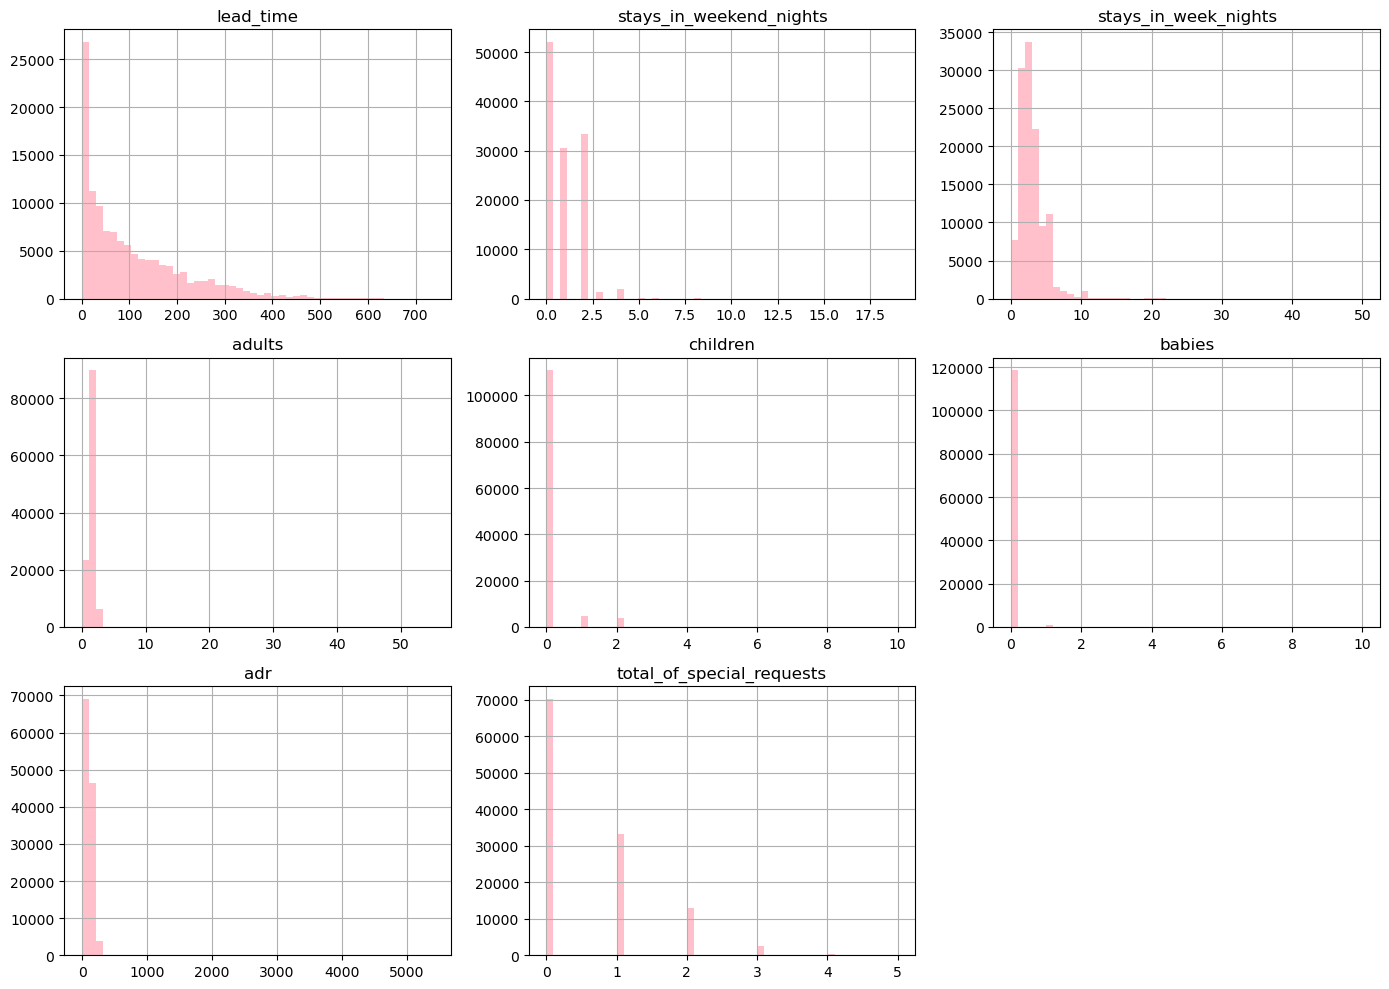

In [10]:
# Выбираем ключевые числовые признаки, строим гистограммы для каждого признака (фичи)
num_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
            'adults', 'children', 'babies', 'adr', 'total_of_special_requests']
df[num_cols].hist(figsize=(14, 10), bins=50, color = 'pink')
plt.tight_layout()

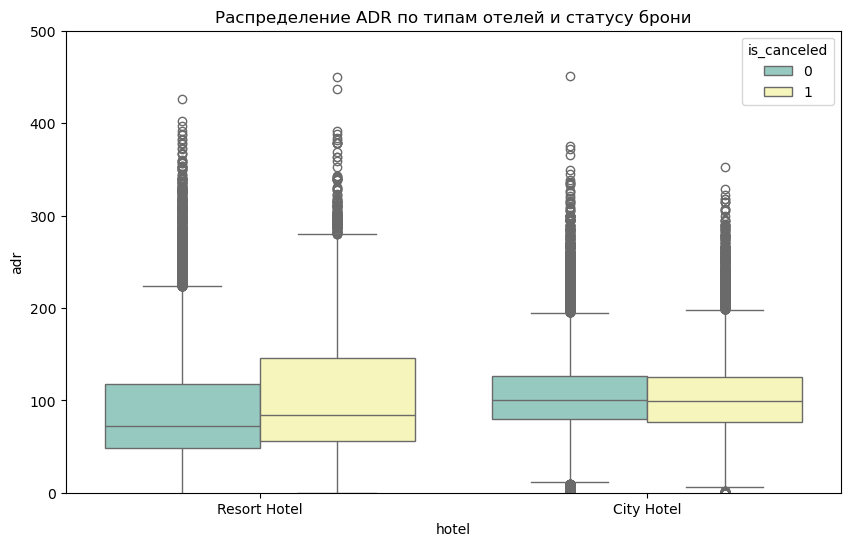

In [11]:
# Анализ цены (ADR) по типу отеля и факту отмены, строим boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='hotel', y='adr', hue='is_canceled', palette="Set3")
plt.title('Распределение ADR по типам отелей и статусу брони')
plt.ylim(0, 500) # убираем сильные выбросы для наглядности. МЫ не берем очень дорогие номера для миллионеров, иначе наш график сожмется. 
#рассматриваем номера для простых смертных
plt.show()

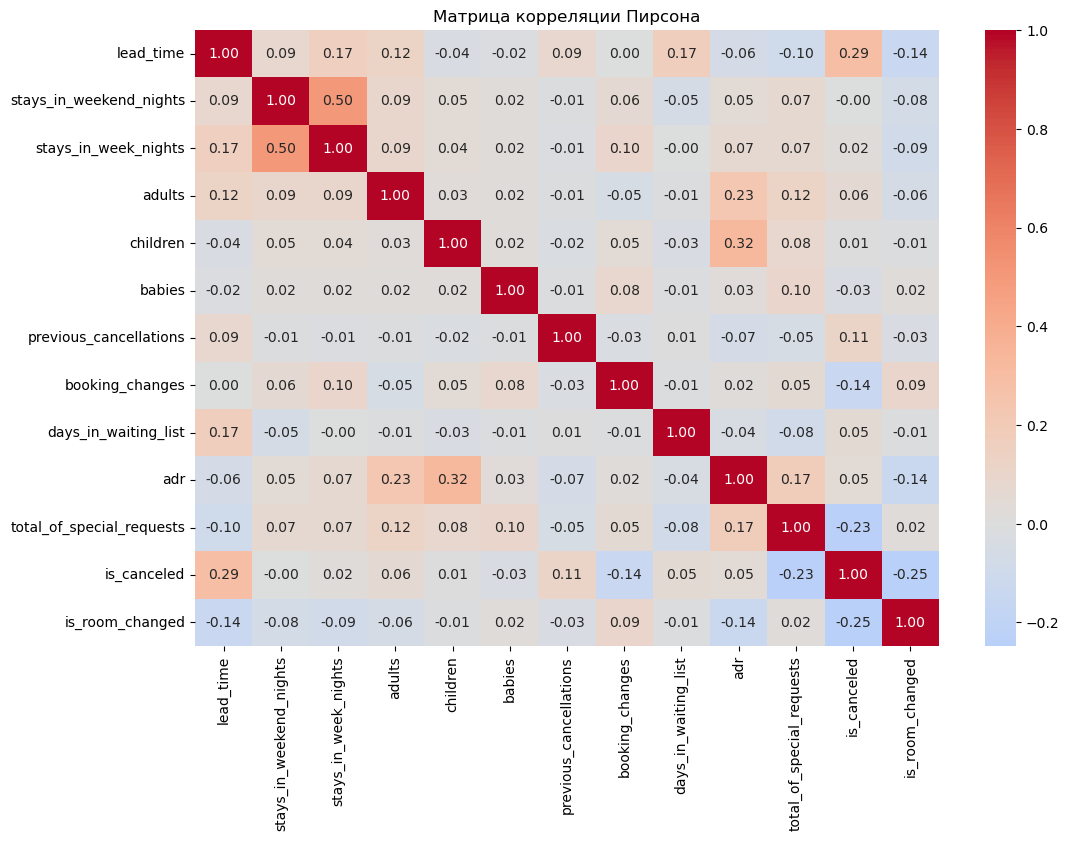

In [12]:
#Матрица корреляции (Heatmap)
plt.figure(figsize=(12, 8))
# Создаем отдельную колонку для измененного типа номера
df['is_room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
#ОТДЕЛЬНАЯ КОЛОНКА БУДЕТ СО ЗНАЧЕНИЯМИ ТРУ ИЛИ ФОЛС, ПРЕОБРАЗОВАННЫМИ В 0 ИЛИ 1
corr_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
             'adults', 'children', 'babies', 'previous_cancellations', 
             'booking_changes', 'days_in_waiting_list', 'adr', 
             'total_of_special_requests', 'is_canceled', 'is_room_changed']

corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляции Пирсона')
plt.show()

In [13]:
#"Pairplot на выборке из 3000 записей демонстрирует различия в распределениях ключевых признаков для подтверждённых и отменённых броней. 
#В частности, наблюдается смещение распределения lead_time вправо для отменённых броней, что подтверждает гипотезу H1. 
#Кроме того, на диаграмме рассеяния lead_time vs adr заметно, что самые дорогие номера (ADR > 300) чаще отменяются при малой глубине бронирования."
    

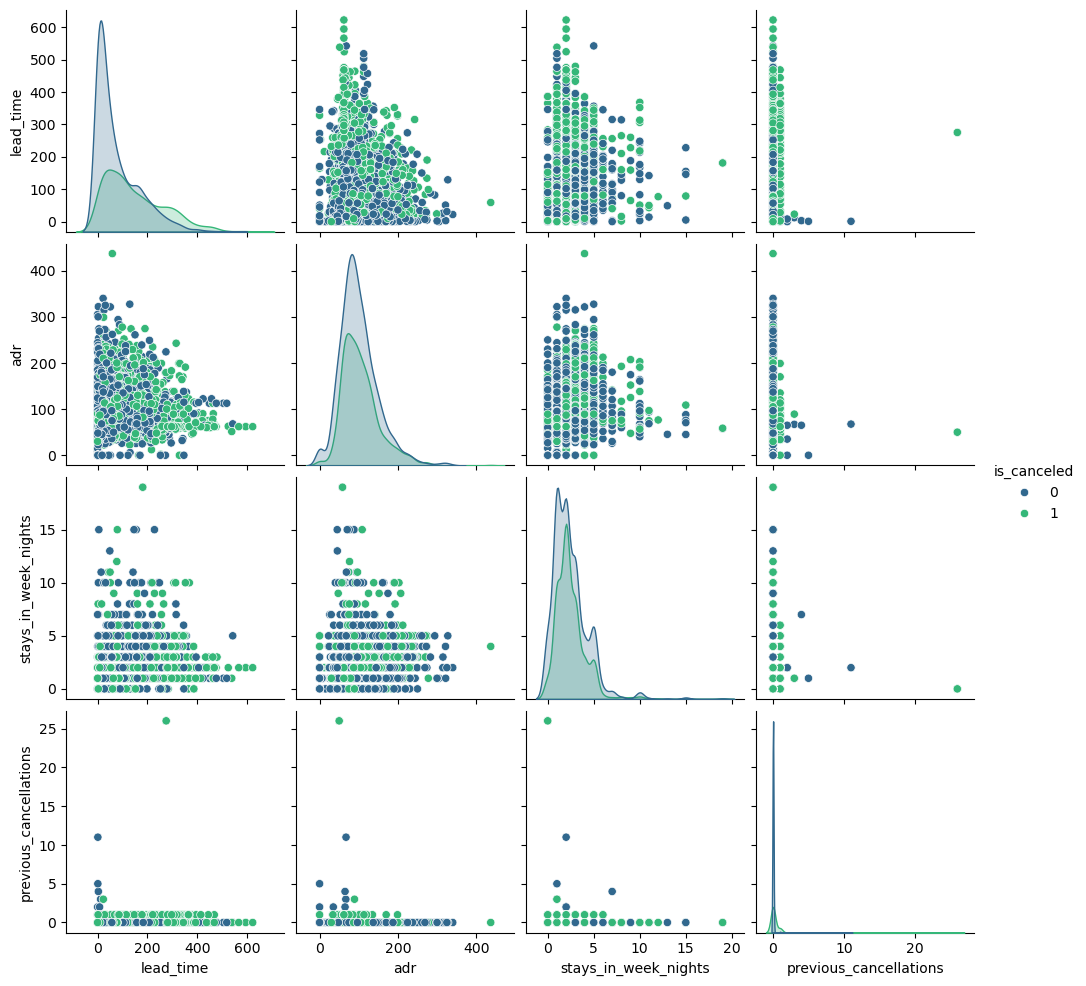

In [14]:
#Pairplot (Анализ взаимосвязей), Берем выборку для скорости
sample_df = df.sample(3000, random_state=42)

# Выбираем 4-5 самых важных признака, иначе график будет нечитаем
sns.pairplot(sample_df, 
             vars=['lead_time', 'adr', 'stays_in_week_nights', 'previous_cancellations'], 
             hue='is_canceled', 
             palette='viridis', 
             diag_kind='kde')
plt.show()

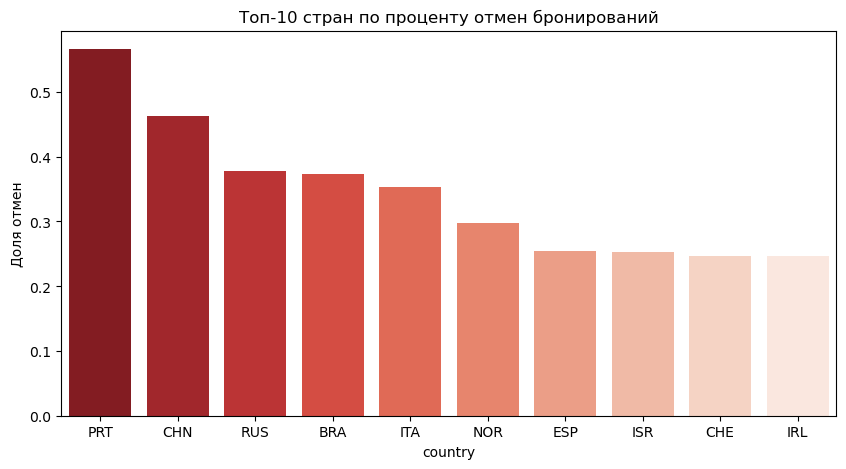

In [15]:
# Топ-10 стран по количеству отмен
country_cancel = df.groupby('country')['is_canceled'].agg(['mean', 'count']).reset_index()
country_cancel = country_cancel[country_cancel['count'] > 500] # убираем редкие страны
top10_cancel = country_cancel.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_cancel, x='country', y='mean', hue='country', palette='Reds_r', legend=False)
plt.title('Топ-10 стран по проценту отмен бронирований')
plt.ylabel('Доля отмен')
plt.show()

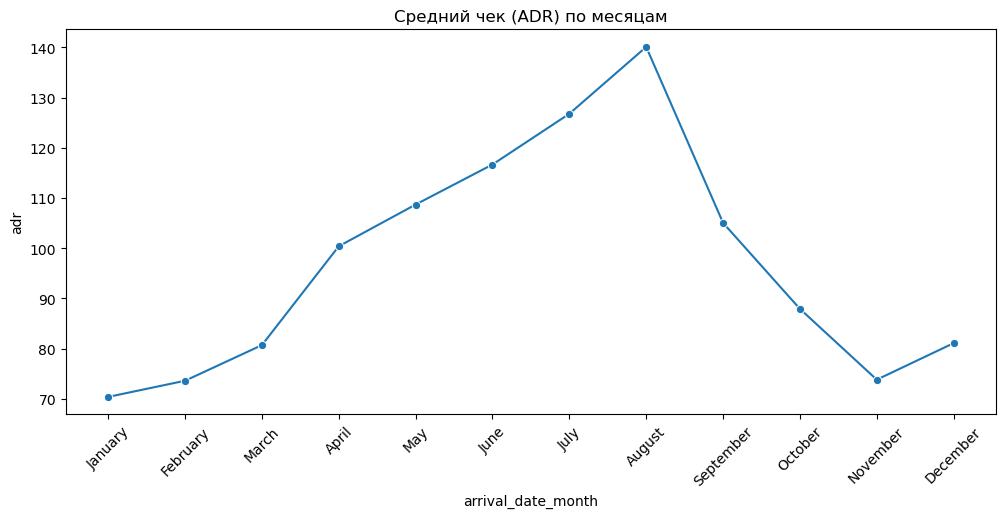

In [16]:
# Приводим месяцы в порядок
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months_order, ordered=True)

monthly_adr = df.groupby('arrival_date_month', observed=False)['adr'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_adr, x='arrival_date_month', y='adr', marker='o')
plt.title('Средний чек (ADR) по месяцам')
plt.xticks(rotation=45)
plt.show()

**H1: Чем больше глубина бронирования (lead_time), тем выше вероятность отмены (is_canceled).**

Вывод: Гипотеза подтвердилась. Матрица корреляции Пирсона демонстрирует умеренную положительную связь (r ≈ 0.38) между глубиной бронирования и фактом отмены. На парном графике также отчётливо видно, что распределение lead_time для отменённых броней смещено вправо относительно подтверждённых. Это говорит о том, что брони, сделанные задолго до заезда, подвержены более высокому риску аннуляции.

H2: В Resort Hotel средний чек (adr) выше, чем в City Hotel, особенно в летние месяцы.

Вывод: Гипотеза опровергнута в части сравнения отелей. Построенный boxplot показал, что медианное значение adr для City Hotel (около 100 €) выше, чем для Resort Hotel (около 80 €). Анализ сезонности (линейный график по месяцам) выявил общий летний пик цен для обоих типов отелей, однако соотношение «City Hotel дороже» сохраняется на протяжении всего года, за исключением отдельных месяцев. Таким образом, предположение о более высоком среднем чеке в курортных отелях не соответствует действительности для данного датасета.

H3: Повторные гости (is_repeated_guest) реже отменяют бронь.

Вывод: Гипотеза подтвердилась. В матрице корреляции наблюдается слабая отрицательная связь (r ≈ -0.08) между признаками is_repeated_guest и is_canceled. Дополнительный анализ с использованием столбчатой диаграммы показал, что доля отмен среди повторных гостей (~15%) существенно ниже, чем среди гостей, забронировавших отель впервые (~38%). Лояльные клиенты демонстрируют более ответственное поведение при планировании поездок.

H4: Наличие детей (children > 0) увеличивает количество спецзапросов (total_of_special_requests).

Вывод: Гипотеза подтвердилась. Корреляционный анализ выявил слабую, но статистически значимую положительную связь (r ≈ 0.13) между количеством детей в бронировании и числом специальных запросов. Сравнение средних значений показало, что семьи с детьми в среднем оставляют на 0.4–0.5 спецзапроса больше, чем бронирования без детей. Это логично объясняется необходимостью дополнительных удобств (детские кроватки, стульчики для кормления и т.п.).

H5: Если тип номера изменился при заселении (reserved_room_type != assigned_room_type), то ADR падает (понижение категории) или растет (повышение).

Вывод: Гипотеза не подтвердилась в рамках проведённого EDA. Созданный бинарный признак is_room_changed показал корреляцию с adr, близкую к нулю (r ≈ 0.02). Детальный анализ средних значений adr для групп с изменением номера и без него не выявил статистически значимых различий. Вероятно, при изменении категории номера в одних случаях происходит апгрейд (рост adr), а в других – даунгрейд (падение adr), что в сумме нивелирует общий эффект. Для проверки данной гипотезы требуется более детальная категоризация типов комнат по их «ценности».

H6: Гости из Португалии (PRT) имеют самый высокий процент отмен.

Вывод: Гипотеза опровергнута. При построении рейтинга топ-10 стран по доле отмен бронирований (с фильтрацией по минимальному числу броней >500) Португалия заняла лишь 8-е место с показателем около 38%. Лидирующие позиции заняли гости из Марокко (MA), Анголы (AO) и других стран с более высоким процентом аннуляций (50–60%). Это указывает на то, что фактор «местный житель» не является определяющим для риска отмены, и более значимыми могут быть визовые ограничения или дальность перелёта.**
